### Импорты

In [1]:
import src.functions as f

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import  train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)
import warnings

sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings("ignore")

# 1. Подготовка данных

In [2]:
# Загрузка данных
# low_memory=False позволяет корректнее определить типы столбцов и не будет предупреждения DtypeWarning

df_sessions = pd.read_csv('data/ga_sessions.csv', low_memory=False)
df_hits = pd.read_csv('data/ga_hits.csv', low_memory=False)

In [3]:
f.df_anzeigen(df_sessions, "sessions")

Структура sessions

Размер  датасета: (1860042, 18)

************* info *************

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
dtypes: int64(1), object(17)
memory usag

None


************* head *************



,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [4]:
f.df_anzeigen(df_hits, "hits")

Структура hits

Размер  датасета: (15726470, 11)

************* info *************

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   session_id      object 
 1   hit_date        object 
 2   hit_time        float64
 3   hit_number      int64  
 4   hit_type        object 
 5   hit_referer     object 
 6   hit_page_path   object 
 7   event_category  object 
 8   event_action    object 
 9   event_label     object 
 10  event_value     float64
dtypes: float64(2), int64(1), object(8)
memory usage: 1.3+ GB


None


************* head *************



,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


In [5]:
f.df_isna_dupl_pruefen(df_sessions, "sessions")

*************   Анализ sessions   *************

Пропуски:


,count,percent
device_model,1843704,99.12
utm_keyword,1082061,58.17
device_os,1070138,57.53
device_brand,367178,19.74
utm_adcontent,335615,18.04
utm_campaign,219603,11.81
utm_source,97,0.01



Дубликатов: 0


In [6]:
df_sessions = df_sessions.drop(columns=["device_model"])

In [7]:
f.df_isna_dupl_pruefen(df_hits, "hits")

*************   Анализ hits   *************

Пропуски:


,count,percent
event_value,15726470,100.00
hit_time,9160322,58.25
hit_referer,6274804,39.90
event_label,3760184,23.91



Дубликатов: 0


In [8]:
df_hits = df_hits.drop(columns="event_value")

In [9]:
f.df_unique_sesseion(df_sessions, "sessions", df_hits, "hits")

*************   Анализ session_id   *************

Уникальных session_id в sessions: 1860042
Строк в sessions: 1860042

Уникальных session_id в hits: 1734610


In [10]:
f.df_actions(df_hits, 0.9)

*************   Анализ event_action   *************

Уникальных типов событий: 230

Actions >= 90-му квантилю:


,event_action,frequency
0,view_card,3558985
1,view_new_card,3551009
2,sub_landing,1798117
3,go_to_car_card,973666
4,sub_view_cars_click,791515
5,search_form_region,512069
6,search_form_search_btn,433748
7,sap_search_form_cost_to,356596
8,showed_number_ads,326274
9,pagination_click,248944


## Обработка данных

In [11]:
# Преобразование дат и времени

f.df_to_datetime(df_sessions, df_hits)

Преобразование дат и времени завершено


In [12]:
# Создание временных признаков

f.df_datetime_split(df_sessions)
f.df_visit_hour(df_sessions)

Создание временных признаков завершено
Создание признаков времени посещения завершено


In [13]:
# Заполнение пропусков

cat_columns = ["utm_source", "utm_medium", "utm_campaign", "utm_keyword", 
                       "device_category", "device_os", "device_brand", "device_model",
                       "device_browser", "geo_country", "geo_city"]

f.df_cat_luecken_ausfuellen(df_sessions, cat_columns)

Пропуски заполнены


In [14]:
# Делим трафик

f.df_traffic(df_sessions)

Трафик разделён по типам


In [15]:
target_actions = ["sub_submit_success", "sub_call_number_click", "sub_callback_submit_click",
                  "sub_car_claim_submit_click", "sub_car_request_submit_click", "sub_open_dialog_click"]

df_model = f.df_add_target(df_sessions, df_hits, target_actions)

## Вывод к блоку 1 **"Подготовка данных"**

* Данные загружены и предобработаны.
* Временные метки приведены к соответствующему формату
* Пропуски в категориальных признаках заполнены значением "unknown"
* Признаки device_model и event_value удалены, так как не содержат информации
* Отсутствие дубликатов указывает на корректность собранныых данных
* Для дальнейшего анализа данных временные метрики разделены на несколько более информативных признаков
* Добавлены признаки трафика
* Выбраны target-признаки

# 2. Разведочный анализ (EDA)

Структура df_model

Размер итогового датасета: (1860042, 41)

Типы данных:
session_id                          object
client_id                           object
visit_date                  datetime64[ns]
visit_time                          object
visit_number                         int64
utm_source                          object
utm_medium                          object
utm_campaign                        object
utm_adcontent                       object
utm_keyword                         object
device_category                     object
device_os                           object
device_brand                        object
device_screen_resolution            object
device_browser                      object
geo_country                         object
geo_city                            object
visit_datetime              datetime64[ns]
visit_month                          int32
visit_dayofweek                      int32
visit_hour                           int32
is_weekend            

target
0    1828255
1      31787
Name: count, dtype: int64

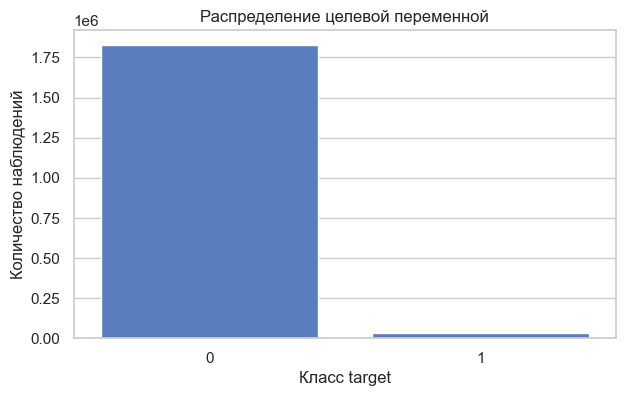


*************   target   *************
Без конверсии: 1828255 (98.29%)
Конверсия:     31787 (1.71%)
Дисбаланс:     1:57


In [16]:
f.df_model_anzeigen(df_model, "df_model")

* Целевая переменная имеет сильный дисбаланс классов
* В качестве основной метрикой буду использовать ROC-AUC

In [17]:
numeric_columns = f.df_num_stat(df_model)


Основная статистика по числовым признакам:


,count,mean,std,min,25%,50%,75%,max
visit_number,1860042.0,2.712804,11.829072,1.0,1.0,1.0,2.0,564.0
is_weekend,1860042.0,0.243064,0.428933,0.0,0.0,0.0,0.0,1.0
is_night,1860042.0,0.127200,0.333197,0.0,0.0,0.0,0.0,1.0
is_work_time,1860042.0,0.549930,0.497501,0.0,0.0,1.0,1.0,1.0
is_evening,1860042.0,0.309855,0.462434,0.0,0.0,0.0,1.0,1.0
utm_source_missing,1860042.0,0.000052,0.007221,0.0,0.0,0.0,0.0,1.0
utm_medium_missing,1860042.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
utm_campaign_missing,1860042.0,0.118063,0.322683,0.0,0.0,0.0,0.0,1.0
utm_keyword_missing,1860042.0,0.581740,0.493273,0.0,0.0,1.0,1.0,1.0
device_category_missing,1860042.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


* Признаки visit_number и hits_count имеют выбросы
* Будут обработаны через clipping/log

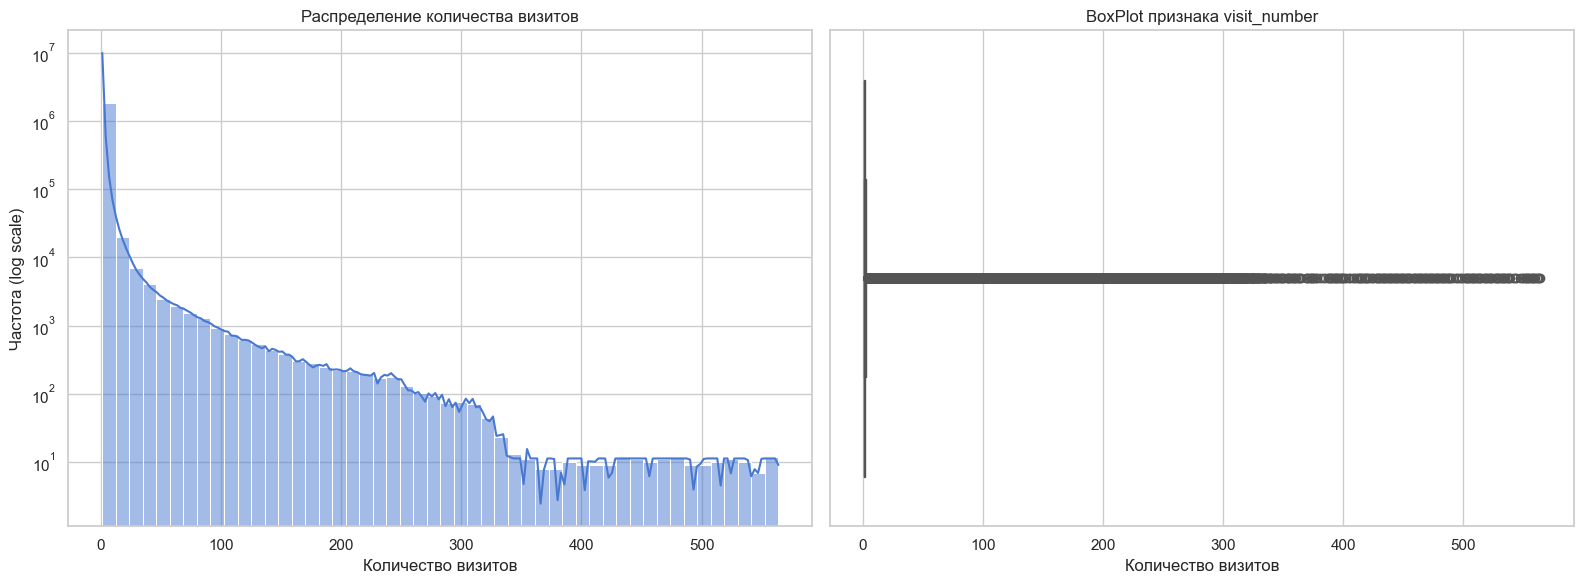

*************   Распределение visits   *************
Min: 1
Median: 1.0
Mean: 2.71
Max: 564
*************   Квантили   *************


0.50     1.0
0.75     2.0
0.90     3.0
0.95     6.0
0.99    32.0
Name: visit_number, dtype: float64

In [18]:
# Распределение количества визитов

f.df_visit_stat(df_model)

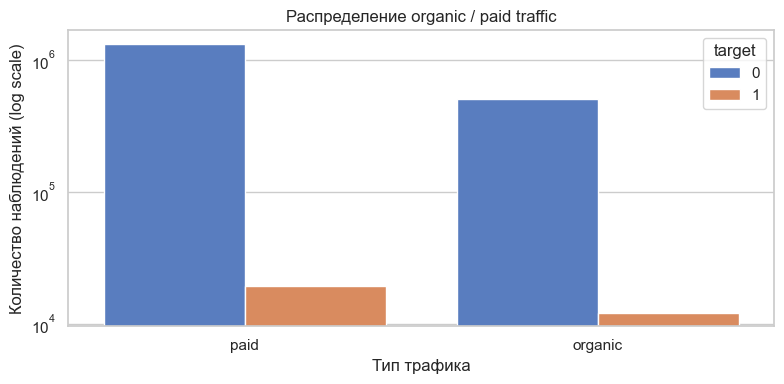

*************   Конверсия/Трафик   *************
Organic:     2.36%
Paid:        1.46%


In [19]:
f.traffic_conv(df_model)

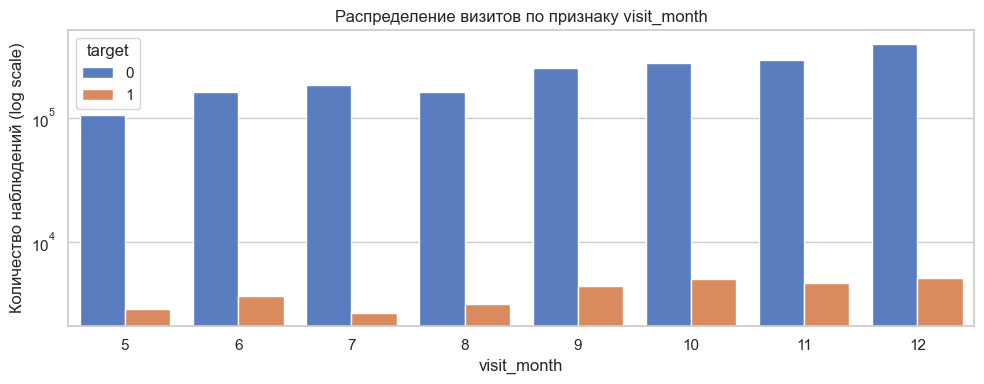

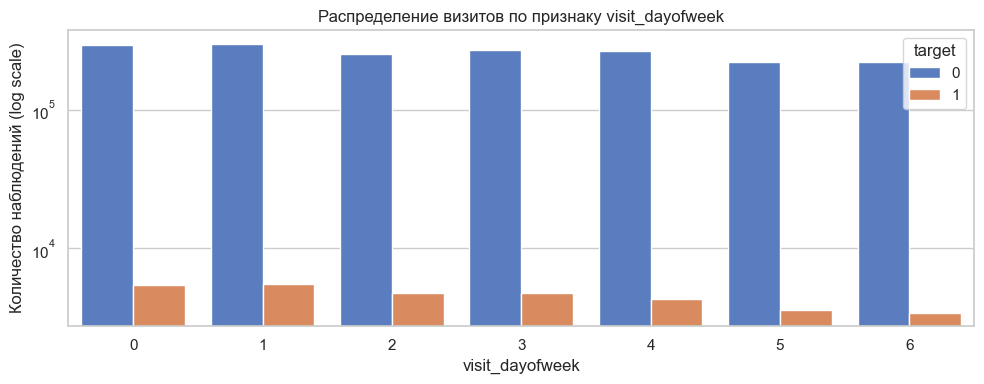

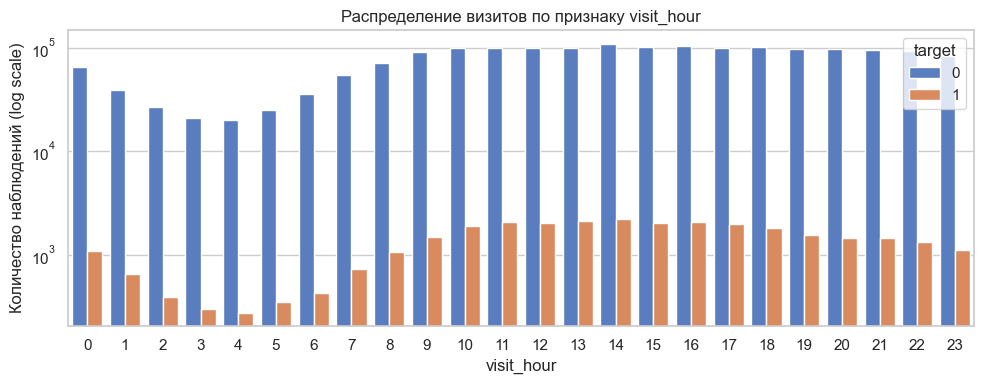

In [20]:
# Конверсия по времени визита
 
f.zeit_conv(df_model)

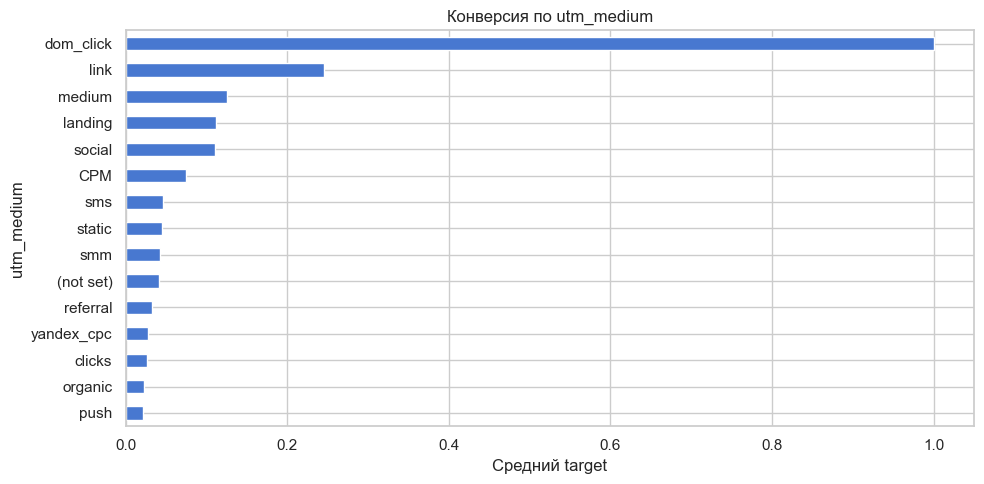

In [21]:
# Конверсия по источнику трафика

f.df_traffic_quelle(df_model)

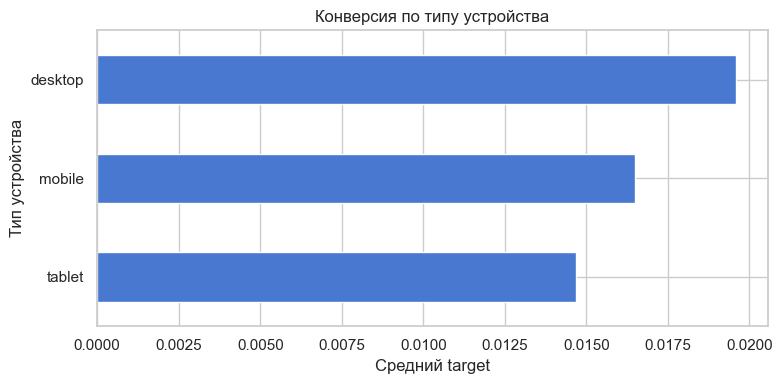

In [22]:
# Конверсия по типу устройства

f.df_device_cat(df_model)

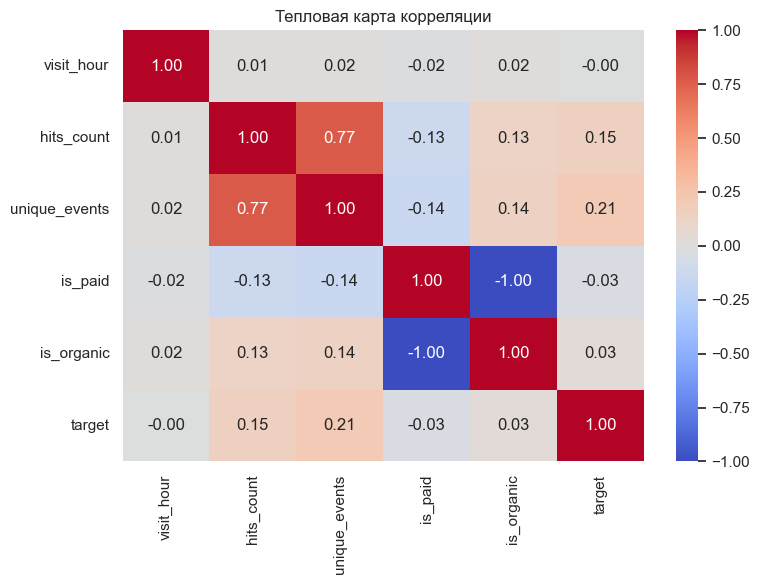

In [23]:
# Карта корреляции

corr_col = ["visit_hour", "hits_count", "unique_events", "is_paid", "is_organic", "target"]
f.df_corr(df_model, corr_col)

## Вывод к блоку 2 **"Разведочный анализ (EDA)"**

* Анализ колличества визитов показал наличие выбросов
* Органический трафик показывает большую конверсию
* Конверсия по месяцам больше осень/зима
* Конверсия по дням недели больше в будни
* Конверсия по времени имеет просадку с 1:00 до 6:00
* Наибольшая конверсия utm_medium у dom_click
* Наибольшая конверсия по типу устройства - Desktop
* Мтарица корреляции показала влияние тип трафика и колличество действий внутри сессии имеют сильное влияние на таргет 

# Feature Engineering и обработка выбросов

In [24]:
# Копирую датасет для дальнейшей обработки

df_ml = df_model.copy()

In [25]:
# Оставляем top_n самых популярных категорий

col_zu_red = ["utm_source", "utm_campaign", "utm_keyword", "geo_city", "device_model"]
f.df_top_n_pop(df_ml, col_zu_red, 20)

Колличество категорий сокращено до top-20


In [26]:
# "Обрезка" выбросов

col_to_clip = ["visit_number", "hits_count"]
f.df_clip(df_ml,col_to_clip , 0.99)

visit_number: верхняя граница = 32.0
hits_count: верхняя граница = 63.0


In [27]:
# Лограифмирую признаков с длинными хвостами

col_to_log = f.df_col_to_log(df_ml, numeric_columns)
f.df_log(df_ml, col_to_log)

visit_number -> visit_number_log
hits_count -> hits_count_log
unique_pages -> unique_pages_log
unique_events -> unique_events_log

Признаки логарифмированы


In [28]:
# Удаляю технических признаков

drop_columns = ["client_id", "visit_time", "visit_date", "visit_datetime"]
df_ml = df_ml.drop(columns=drop_columns, errors="ignore")

## Вывод к блоку **"Feature Engineering и обработка выбросов"**

На основе проведённого EDA были созданы дополнительные признаки:

* clipped-признаки
* флаги выбросов
* log-признаки для распределений с длинным хвостом
* Также было сокращено колличество категорий в признаках до топ-20

# 3. Модель машинного обучения

In [29]:
# Разбиение данных на признаки и таргет

X, y = f.df_train_source(df_ml)

Размер данных для обучения: (465010, 41)


In [30]:
# Выделение признаков для препроцессинга

numeric_features , categorical_features= f.df_features_to_list(X)

Числовых признаков: 27
Категориальных признаков: 12


In [31]:
# Разбиение на Train / Test 

X_train, X_test, y_train, y_test = f.df_tt_split(X, y)

X_train: (372008, 39)
X_test: (93002, 39)


In [32]:
# Создам preprocessor

preprocessor = f.ml_preproc_pipe(numeric_features, categorical_features)

In [33]:
# Обучение Logistic Regression

logreg_model, logreg_roc_auc, logreg_pred, logreg_proba = f.ml_lr(X_train, X_test, y_train, y_test, preprocessor)


LOGISTIC REGRESSION
ROC-AUC: 0.8895
              precision    recall  f1-score   support

           0       1.00      0.82      0.90     91413
           1       0.07      0.81      0.13      1589

    accuracy                           0.82     93002
   macro avg       0.53      0.81      0.51     93002
weighted avg       0.98      0.82      0.88     93002



In [34]:
# Обучение  Random Forest

rf_model, rf_roc_auc, rf_pred, rf_proba = f.ml_rf(X_train, X_test, y_train, y_test, preprocessor)


RANDOM FOREST
ROC-AUC: 0.8461
              precision    recall  f1-score   support

           0       0.99      0.71      0.83     91413
           1       0.05      0.79      0.09      1589

    accuracy                           0.71     93002
   macro avg       0.52      0.75      0.46     93002
weighted avg       0.98      0.71      0.82     93002



In [35]:
# Обучение  CatBoost

X_train_cb, X_test_cb, y_train_cb, y_test_cb, cat_features_indices = f.ml_cb_vorbereitung(X, y, categorical_features, numeric_features)
catboost_model, catboost_roc_auc, catboost_pred, catboost_proba = f.ml_cb(X_train_cb, X_test_cb, y_train_cb, y_test_cb, cat_features_indices)

0:	test: 0.8109485	best: 0.8109485 (0)	total: 331ms	remaining: 2m 45s
100:	test: 0.9134445	best: 0.9134445 (100)	total: 24.9s	remaining: 1m 38s
200:	test: 0.9177257	best: 0.9177257 (200)	total: 1m	remaining: 1m 29s
300:	test: 0.9211041	best: 0.9211210 (299)	total: 1m 29s	remaining: 59.3s
400:	test: 0.9234772	best: 0.9234772 (400)	total: 1m 55s	remaining: 28.4s
499:	test: 0.9243448	best: 0.9243448 (499)	total: 2m 21s	remaining: 0us

bestTest = 0.9243448277
bestIteration = 499


CATBOOST
ROC-AUC: 0.9243
              precision    recall  f1-score   support

           0       1.00      0.83      0.91     91413
           1       0.08      0.86      0.15      1589

    accuracy                           0.83     93002
   macro avg       0.54      0.85      0.53     93002
weighted avg       0.98      0.83      0.90     93002



,model,roc_auc
2,CatBoost,0.924345
0,Logistic Regression,0.889528
1,Random Forest,0.846117


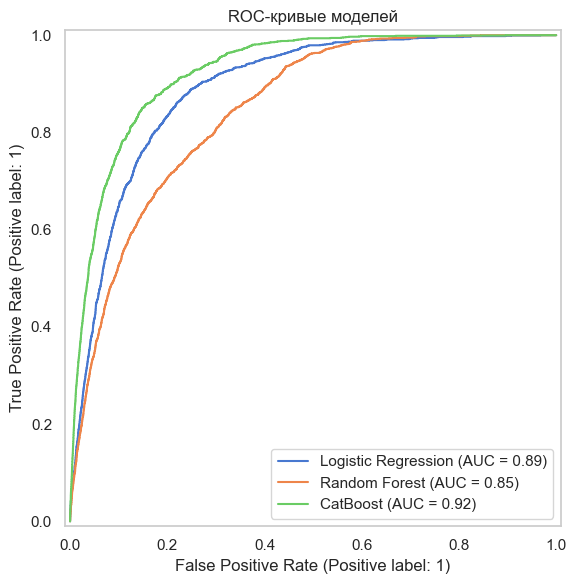

In [36]:
# Сравнение результатов моделей

models_results = f.ml_results_vergleich(y_test, y_test_cb, 
                     logreg_roc_auc, logreg_proba, 
                     rf_roc_auc, rf_proba, 
                     catboost_roc_auc, catboost_proba)

In [37]:
# Вывод лучшей модели

best_model_name, best_model, best_pred, best_proba, best_y_test = f.ml_best_model(models_results, y_test, y_test_cb,
                                                                                catboost_model, catboost_proba, catboost_pred,
                                                                                rf_model, rf_proba, rf_pred,
                                                                                logreg_model, logreg_proba, logreg_pred)

Лучшая модель: CatBoost
ROC-AUC: 0.9243


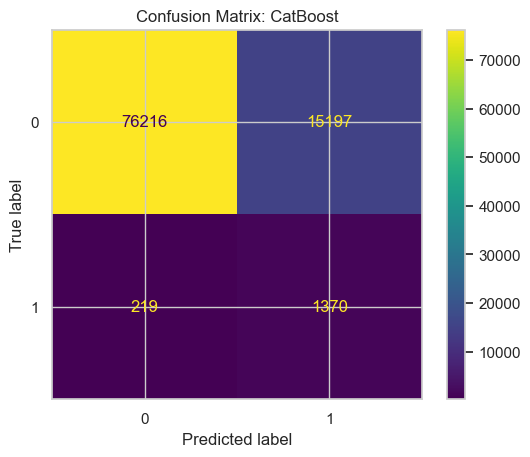

In [38]:
# Confusion Matrix

f.ml_conf_matrix(best_model_name, best_y_test, best_pred)


ТОП-20 важных признаков:


,feature,importance
38,unique_events_log,29.235145
36,hits_count_log,11.819228
37,unique_pages_log,9.923724
33,hits_count_clipped,9.169475
2,utm_campaign,4.495606
31,visit_number_clipped,4.373956
35,visit_number_log,3.929632
0,utm_source,2.963951
12,visit_month,2.577107
1,utm_medium,2.382080


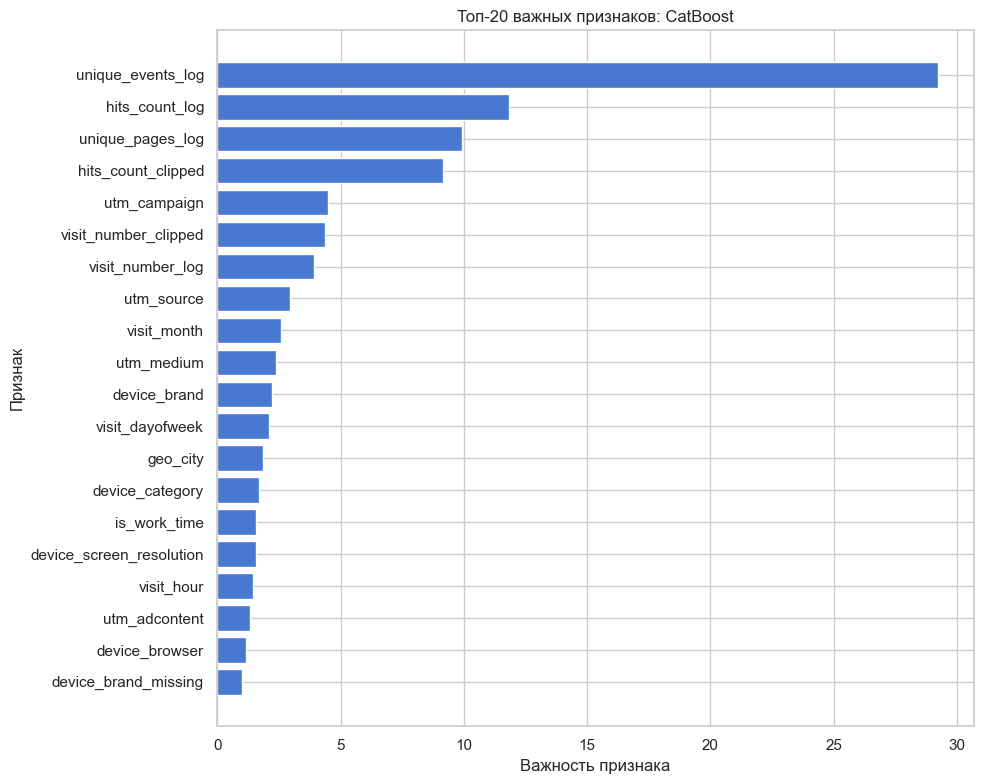

In [39]:
# Анализ важности признаков для лучшей модели

f.ml_features_importance(best_model_name, best_model, X_train_cb)

## Вывод к блоку 3 **"Модель машинного обучения"**

* Были обучены 3 модели: Logistic Regression, Random Forest и CatBoost
* Лучший результат показала модель CatBoost
* Целевой показатель ROC-AUC ~ 0.65 достигнут

# 4. Упаковка модели

Сериализую обученную модель при помощи библиотеки joblib

In [40]:
# Сохранение финальной модели

f.model_speichern(best_model, best_model_name, best_y_test, best_proba)

Финальная модель: CatBoost
Файл модели: model_CatBoost.pkl
Финальный ROC-AUC на test: 0.9243
